In [13]:
import matplotlib.pyplot as plt

from src.load_data import *
from src.preprocess import *

### Load Data

In [6]:
filepath = "data/GlobalWeatherRepository.csv"
df = load_raw_data(filepath)
df_original = df.copy()

df = standardize_columns(df)

df = parse_datetime_local(df)

df = parse_datetime_unix(df)

df = drop_duplicates(df)

#df = create_timeseries_index(df)

In [7]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_pm2.5,air_quality_pm10,air_quality_us_epa_index,air_quality_gb_defra_index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 08:45:00+00:00,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 08:45:00+00:00,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 08:45:00+00:00,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 08:45:00+00:00,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 08:45:00+00:00,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


### Preprocess data

In [9]:
# Missingness table
miss = missingness_summary(df)
df.isna().any().any()

np.False_

In [10]:
# Numeric columns
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()

# Exclude time columns and co-ordinates from numeric columns
exclude_cols = {
    "last_updated", "last_updated_epoch", "sunrise", "sunset", "moonrise", "moonset",
    "latitude", "longitude" 
}

cols_for_outliers = [c for c in numeric_cols if c not in exclude_cols]

In [11]:
df_with_flags = flag_outliers(df, cols_for_outliers)

In [12]:
# Calculate outliers per column
outlier_counts = (
    df_with_flags[[f"{c}_outlier" for c in cols_for_outliers]]
    .sum()
    .sort_values(ascending=False)
)

# Top 10 columns with most outliers
outlier_counts.head(10)

air_quality_sulphur_dioxide_outlier     24487
air_quality_nitrogen_dioxide_outlier    19253
air_quality_pm10_outlier                14025
air_quality_carbon_monoxide_outlier     11025
air_quality_gb_defra_index_outlier      10655
air_quality_pm2.5_outlier               10389
pressure_in_outlier                      3392
temperature_celsius_outlier              2272
temperature_fahrenheit_outlier           2270
gust_mph_outlier                         2034
dtype: int64

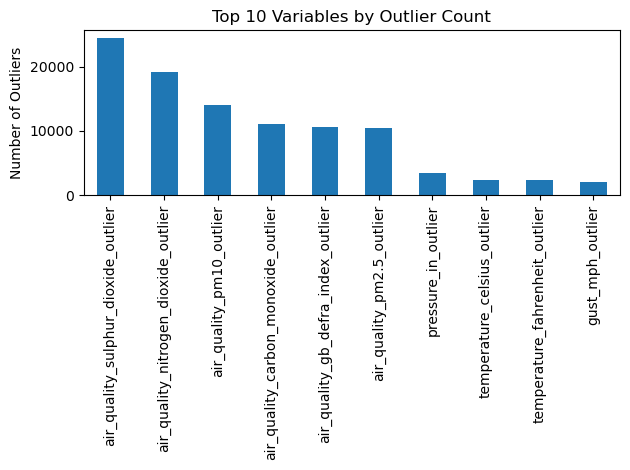

In [18]:
# Top 10 columns with most outliers - visualization

plt.figure()
outlier_counts[:10].plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Top 10 Variables by Outlier Count")
plt.ylabel("Number of Outliers")
plt.tight_layout()
#plt.savefig("top_outliers.png")
plt.show()

In [17]:
# Feature scaling
cols_to_scale = cols_for_outliers
df_scaled = apply_robust_scaler(df, cols_to_scale)